In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data/processed")

df = pd.read_csv(DATA_DIR / "listings_clean.csv")
print(f"Shape : {df.shape}")
df.head(3)

Shape : (59767, 67)


,id,latitude,longitude,room_type,accommodates,bedrooms,beds,host_is_superhost,host_identity_verified,minimum_nights,...,neighbourhood_Merton,neighbourhood_Newham,neighbourhood_Redbridge,neighbourhood_Richmond upon Thames,neighbourhood_Southwark,neighbourhood_Sutton,neighbourhood_Tower Hamlets,neighbourhood_Waltham Forest,neighbourhood_Wandsworth,neighbourhood_Westminster
0,13913,51.56861,-0.11270,1,1,1.0,1.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,15400,51.48780,-0.16813,3,2,1.0,1.0,0,1,4,...,0,0,0,0,0,0,0,0,0,0
2,17402,51.52195,-0.14094,3,6,3.0,3.0,1,1,3,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split

# Séparer features et cible
X = df.drop(columns=['price'])
y = df['price']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape}")
print(f"Test : {X_test.shape}")

Train : (47813, 65)
Test : (11954, 65)


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline : toujours prédire la médiane
y_pred_baseline = np.full(len(y_test), y_train.median())

mae = mean_absolute_error(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2 = r2_score(y_test, y_pred_baseline)

print(f"=== BASELINE (médiane) ===")
print(f"MAE  : {mae:.2f}£")
print(f"RMSE : {rmse:.2f}£")
print(f"R²   : {r2:.4f}")

=== BASELINE (médiane) ===
MAE  : 95.57£
RMSE : 152.42£
R²   : -0.0721


In [27]:
from sklearn.linear_model import LinearRegression

# Entraîner
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prédire
y_pred_lr = lr.predict(X_test)

# Évaluer
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"=== RÉGRESSION LINÉAIRE ===")
print(f"MAE  : {mae:.2f}£")
print(f"RMSE : {rmse:.2f}£")
print(f"R²   : {r2:.4f}")

=== RÉGRESSION LINÉAIRE ===
MAE  : 62.61£
RMSE : 102.52£
R²   : 0.5149


In [28]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2 = r2_score(y_test, y_pred_dt)

print(f"=== DECISION TREE ===")
print(f"MAE  : {mae:.2f}£")
print(f"RMSE : {rmse:.2f}£")
print(f"R²   : {r2:.4f}")

=== DECISION TREE ===
MAE  : 67.61£
RMSE : 125.91£
R²   : 0.2684


In [29]:
# Comparer les scores train et test
y_pred_train_dt = dt.predict(X_train)

mae_train = mean_absolute_error(y_train, y_pred_train_dt)
r2_train = r2_score(y_train, y_pred_train_dt)

print(f"=== DECISION TREE ===")
print(f"Train - MAE: {mae_train:.2f}£  R²: {r2_train:.4f}")
print(f"Test  - MAE: {66.06:.2f}£  R²: {0.3037:.4f}")
print(f"\nÉcart R² train/test : {r2_train - 0.3037:.4f}")

=== DECISION TREE ===
Train - MAE: 0.01£  R²: 1.0000
Test  - MAE: 66.06£  R²: 0.3037

Écart R² train/test : 0.6963


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_rf_train = rf.predict(X_train)

print(f"=== RANDOM FOREST ===")
print(f"Train - MAE: {mean_absolute_error(y_train, y_pred_rf_train):.2f}£  R²: {r2_score(y_train, y_pred_rf_train):.4f}")
print(f"Test  - MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}£  R²: {r2_score(y_test, y_pred_rf):.4f}")

=== RANDOM FOREST ===
Train - MAE: 18.69£  R²: 0.9494
Test  - MAE: 48.91£  R²: 0.6558


In [31]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_pred_xgb_train = xgb.predict(X_train)

print(f"=== XGBOOST ===")
print(f"Train - MAE: {mean_absolute_error(y_train, y_pred_xgb_train):.2f}£  R²: {r2_score(y_train, y_pred_xgb_train):.4f}")
print(f"Test  - MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}£  R²: {r2_score(y_test, y_pred_xgb):.4f}")

=== XGBOOST ===
Train - MAE: 40.92£  R²: 0.7943
Test  - MAE: 49.18£  R²: 0.6623


In [32]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
y_pred_lgbm_train = lgbm.predict(X_train)

print(f"=== LIGHTGBM ===")
print(f"Train - MAE: {mean_absolute_error(y_train, y_pred_lgbm_train):.2f}£  R²: {r2_score(y_train, y_pred_lgbm_train):.4f}")
print(f"Test  - MAE: {mean_absolute_error(y_test, y_pred_lgbm):.2f}£  R²: {r2_score(y_test, y_pred_lgbm):.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1703
[LightGBM] [Info] Number of data points in the train set: 47813, number of used features: 65
[LightGBM] [Info] Start training from score 175.063560
=== LIGHTGBM ===
Train - MAE: 46.80£  R²: 0.6986
Test  - MAE: 48.87£  R²: 0.6598


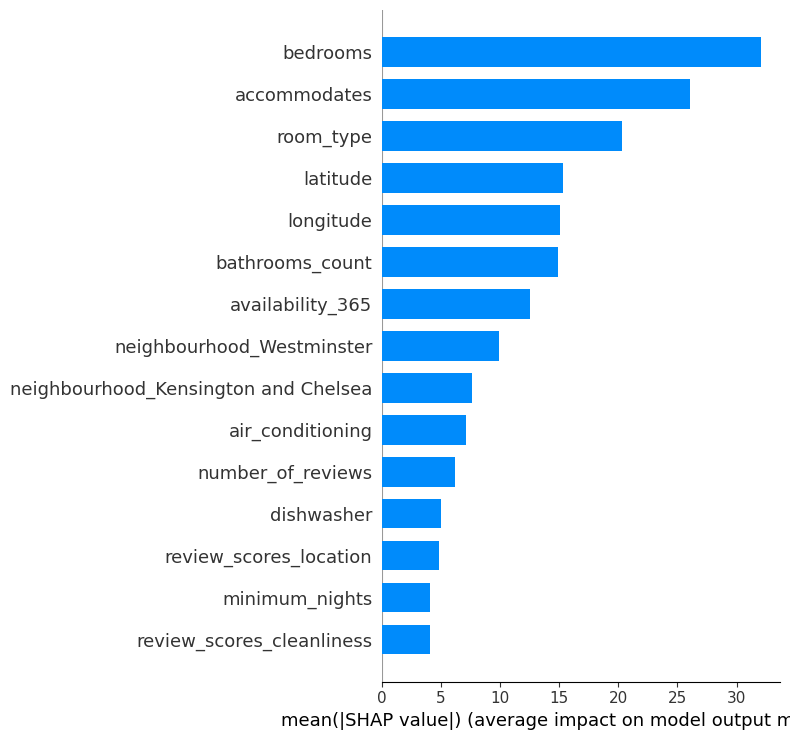

In [33]:
import shap

# Calculer les SHAP values sur un échantillon (1000 lignes pour la rapidité)
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test.iloc[:1000])

# Visualiser les variables les plus importantes
shap.summary_plot(shap_values, X_test.iloc[:1000], plot_type="bar", max_display=15)

In [34]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 100],
    'min_child_samples': [10, 20, 50, 100],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

lgbm_base = LGBMRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    lgbm_base,
    param_distributions=param_grid,
    n_iter=50,          # tester 50 combinaisons aléatoires
    scoring='r2',
    cv=5,               # validation croisée sur 5 folds
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {search.best_params_}")
print(f"Meilleur R² (CV) : {search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003748 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1703
[LightGBM] [Info] Number of data points in the train set: 47813, number of used features: 65
[LightGBM] [Info] Start training from score 175.063560
Meilleurs paramètres : {'subsample': 0.8, 'num_leaves': 100, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Meilleur R² (CV) : 0.6614


In [35]:
# Entraîner avec les meilleurs paramètres
best_lgbm = search.best_estimator_

y_pred_best = best_lgbm.predict(X_test)
y_pred_best_train = best_lgbm.predict(X_train)

print(f"=== LIGHTGBM OPTIMISÉ ===")
print(f"Train - MAE: {mean_absolute_error(y_train, y_pred_best_train):.2f}£  R²: {r2_score(y_train, y_pred_best_train):.4f}")
print(f"Test  - MAE: {mean_absolute_error(y_test, y_pred_best):.2f}£  R²: {r2_score(y_test, y_pred_best):.4f}")

=== LIGHTGBM OPTIMISÉ ===
Train - MAE: 27.17£  R²: 0.9125
Test  - MAE: 46.65£  R²: 0.6885


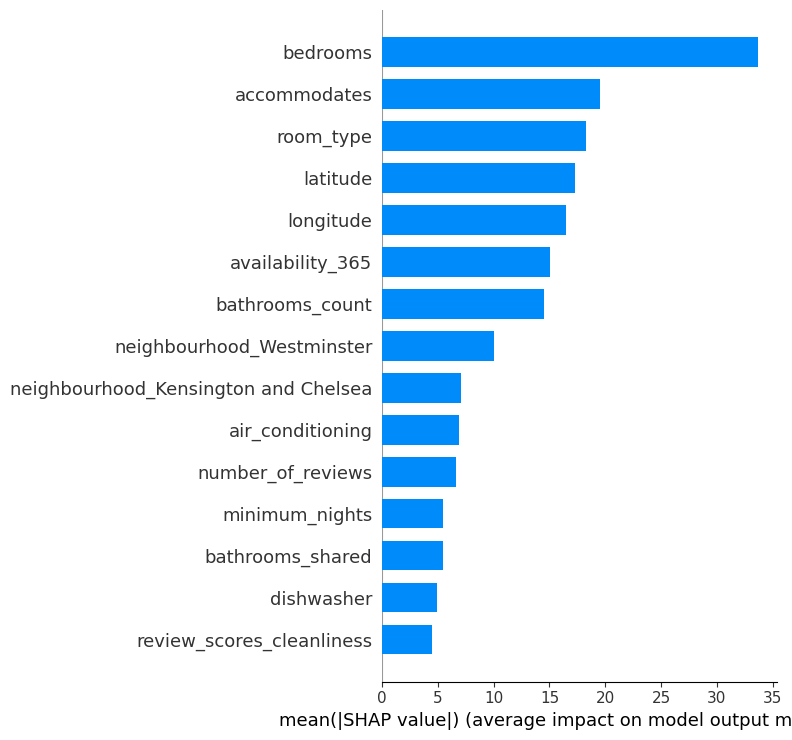

In [36]:
explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test.iloc[:1000])

# Importance globale
shap.summary_plot(shap_values, X_test.iloc[:1000], plot_type="bar", max_display=15)

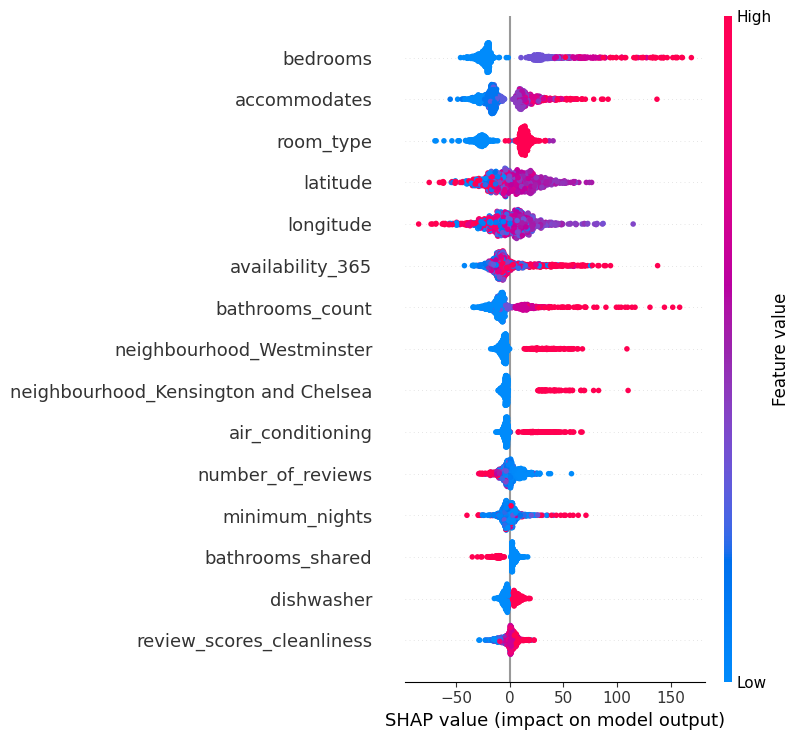

In [37]:
shap.summary_plot(shap_values, X_test.iloc[:1000], max_display=15)

In [38]:
import joblib

# Sauvegarder le modèle
joblib.dump(best_lgbm, "../models/lightgbm_model.pkl")
print("Modèle sauvegardé ✓")

# Sauvegarder aussi les colonnes pour l'API plus tard
import json
feature_names = X_train.columns.tolist()
with open("../models/feature_names.json", "w") as f:
    json.dump(feature_names, f)
print("Features sauvegardées ✓")

Modèle sauvegardé ✓
Features sauvegardées ✓


In [40]:
import pandas as pd
import json

# Charger les colonnes
with open("../models/feature_names.json", "r") as f:
    feature_names = json.load(f)

# Créer 3 logements fictifs
logements = pd.DataFrame(0.0, index=range(3), columns=feature_names)

# Logement 1 : Studio privé à Hackney (quartier abordable)
logements.loc[0, 'room_type'] = 1          # Private room
logements.loc[0, 'accommodates'] = 2
logements.loc[0, 'bedrooms'] = 1
logements.loc[0, 'beds'] = 1
logements.loc[0, 'bathrooms_count'] = 1
logements.loc[0, 'bathrooms_shared'] = 0
logements.loc[0, 'latitude'] = 51.5450
logements.loc[0, 'longitude'] = -0.0553
logements.loc[0, 'neighbourhood_Hackney'] = 1
logements.loc[0, 'wifi'] = 1
logements.loc[0, 'availability_365'] = 200

# Logement 2 : Appartement entier à Westminster (centre premium)
logements.loc[1, 'room_type'] = 3          # Entire home
logements.loc[1, 'accommodates'] = 4
logements.loc[1, 'bedrooms'] = 2
logements.loc[1, 'beds'] = 2
logements.loc[1, 'bathrooms_count'] = 1
logements.loc[1, 'bathrooms_shared'] = 0
logements.loc[1, 'latitude'] = 51.4975
logements.loc[1, 'longitude'] = -0.1357
logements.loc[1, 'neighbourhood_Westminster'] = 1
logements.loc[1, 'wifi'] = 1
logements.loc[1, 'air_conditioning'] = 1
logements.loc[1, 'dishwasher'] = 1
logements.loc[1, 'availability_365'] = 150

# Logement 3 : Grande villa à Kensington (luxe)
logements.loc[2, 'room_type'] = 3          # Entire home
logements.loc[2, 'accommodates'] = 8
logements.loc[2, 'bedrooms'] = 4
logements.loc[2, 'beds'] = 4
logements.loc[2, 'bathrooms_count'] = 3
logements.loc[2, 'bathrooms_shared'] = 0
logements.loc[2, 'latitude'] = 51.5020
logements.loc[2, 'longitude'] = -0.1947
logements.loc[2, 'neighbourhood_Kensington and Chelsea'] = 1
logements.loc[2, 'wifi'] = 1
logements.loc[2, 'air_conditioning'] = 1
logements.loc[2, 'dishwasher'] = 1
logements.loc[2, 'hot_tub'] = 1
logements.loc[2, 'gym'] = 1
logements.loc[2, 'availability_365'] = 100

# Prédire
prix = best_lgbm.predict(logements)

print("=== PRÉDICTIONS ===")
print(f"Studio privé à Hackney      : {prix[0]:.0f}£/nuit")
print(f"Appartement à Westminster   : {prix[1]:.0f}£/nuit")
print(f"Grande villa à Kensington   : {prix[2]:.0f}£/nuit")

=== PRÉDICTIONS ===
Studio privé à Hackney      : 87£/nuit
Appartement à Westminster   : 364£/nuit
Grande villa à Kensington   : 718£/nuit
